<a href="https://colab.research.google.com/github/Priya-DharshiniRamesh/24ADI006_DEEP-LEARNING/blob/main/DL_EXP_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**DEEP LEARNING -24ADI006**

**EXPT NO: 6 IMPLEMENTATION OF LONG SHORT-TERM MEMORY (LSTM) FOR SENTIMENT ANALYSIS**

**Name: Priya Dharshini R**\
**Roll no: 24BAD092**

**AIM**

To implement a Long Short-Term Memory (LSTM) neural network for sentiment analysis and classify textual data into appropriate sentiment categories based on the learned linguistic patterns.

**SOFTWARE REQUIREMENTS**

•	Python

•	TensorFlow / Keras / PyTorch

•	Google Colab

•	GitHub

•	NumPy

•	Matplotlib

•	Pandas

**OBJECTIVES**

**Students will be able to:**

•	Understand the architecture and working of Long Short-Term Memory (LSTM) networks.

•	Understand the role of LSTM in processing sequential textual data.

•	Perform text preprocessing techniques for sentiment classification.

•	Convert textual data into numerical sequences suitable for LSTM models.

•	Build and train an LSTM-based sentiment classification model.

•	Evaluate the performance of the trained LSTM using appropriate classification metrics.

•	Analyze the effectiveness of LSTM in learning contextual and sequential patterns from textual data.


**PART A: DATASET PREPARATION**

**Perform the following tasks:**

•	Load a suitable sentiment analysis dataset such as the IMDB Movie Reviews dataset.

•	Explore the dataset and examine sample reviews and their corresponding sentiment labels.

•	Identify the positive and negative sentiment classes.

•	Perform basic text preprocessing such as converting text to lowercase, if required.

•	Remove unnecessary characters or symbols, if required.

•	Tokenize the reviews into words.

•	Build a vocabulary and assign unique integer indices to words.

•	Convert the text reviews into numerical sequences.

•	Apply sequence padding to obtain inputs of equal length.

•	Split the prepared dataset into training and validation/testing datasets.



In [1]:

# LSTM Sentiment Analysis
import numpy as np
import matplotlib.pyplot as plt
import re
import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences


# Dataset settings
vocab_size = 10000
max_length = 200

# Load the IMDB movie review dataset
(x_train, y_train), (x_test, y_test) = imdb.load_data(
    num_words=vocab_size
)

print("\nDataset Loaded Successfully")
print("Training reviews:", len(x_train))
print("Testing reviews:", len(x_test))

# Display a sample review and its sentiment
print("\nFirst review word IDs:", x_train[0][:20])
print(
    "First review sentiment:",
    "Positive" if y_train[0] == 1 else "Negative"
)

# Convert numerical word IDs into readable words
word_index = imdb.get_word_index()
index_word = {value + 3: key for key, value in word_index.items()}

sample_review = " ".join(
    index_word.get(i, "?") for i in x_train[0] if i > 3
)

print("\nSample Review:")
print(sample_review[:500], "...")

print(
    "Sample Review Label:",
    "Positive" if y_train[0] == 1 else "Negative"
)

# Pad reviews to a fixed length
x_train = pad_sequences(
    x_train,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

x_test = pad_sequences(
    x_test,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

# Split training data into training and validation sets
x_val, y_val = x_train[-5000:], y_train[-5000:]
x_train, y_train = x_train[:-5000], y_train[:-5000]

print("\nDataset Shapes")
print("Training data:", x_train.shape)
print("Validation data:", x_val.shape)
print("Testing data:", x_test.shape)

print("\nPriya Dharshini R | Roll No: 24BAD092")


Dataset Loaded Successfully
Training reviews: 25000
Testing reviews: 25000

First review word IDs: [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]
First review sentiment: Positive

Sample Review:
this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert is an amazing actor and now the same being director father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for and would recommend it to everyone to  ...
Sample Review Label: Positive

Dataset Shapes
Training data: (20000, 200)
Validation data: (5000, 200)
Testing data: (25000, 200)

Priya Dharshini R | Roll No: 24BAD092


**PART B: IMPLEMENTING THE LSTM MODEL**

**Perform the following tasks:**

•	Create an Embedding layer to convert words into dense vector representations.

•	Add an LSTM layer to learn long-term sequential dependencies in the reviews.

•	Add a Dense output layer for sentiment classification.

•	Use an appropriate activation function such as Sigmoid for binary sentiment classification.

•	Compile the model using an appropriate optimizer and loss function.

•	Display the model architecture and model summary.


In [2]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense

# Build the LSTM sentiment classification model
model = Sequential([
    Input(shape=(max_length,)),
    Embedding(
        input_dim=vocab_size,
        output_dim=32,
        mask_zero=True
    ),
    LSTM(32),
    Dense(1, activation="sigmoid")
])

# Compile the model
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Display the model architecture
model.summary()

print("\n Priya Dharshini R | Roll No: 24BAD092")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,353 (1.25 MB)

 Trainable params: 328,353 (1.25 MB)

 Non-trainable params: 0 (0.00 B)


 Priya Dharshini R | Roll No: 24BAD092


**PART C: MODEL TRAINING AND PERFORMANCE EVALUATION**

**Perform the following tasks:**

•	Train the LSTM model using the prepared training dataset.

•	Validate the model using the validation dataset.

•	**Record:**

o	Training accuracy

o	Validation accuracy

o	Training loss

o	Validation loss

•	Evaluate the trained model on the test dataset.

•	**Calculate suitable evaluation metrics such as:**

o	Accuracy

o	Precision

o	Recall

o	F1-score

**•	Generate a confusion matrix to analyze the classification performance.**

•	**Visualize:**

o	Accuracy vs. Epoch

o	Loss vs. Epoch



Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 35s 212ms/step - accuracy: 0.7260 - loss: 0.5225 - val_accuracy: 0.8564 - val_loss: 0.3522
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 33s 163ms/step - accuracy: 0.8839 - loss: 0.2955 - val_accuracy: 0.8606 - val_loss: 0.3282
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 163ms/step - accuracy: 0.9187 - loss: 0.2209 - val_accuracy: 0.8574 - val_loss: 0.3591

Training and Validation Results

Epoch 1
Training Accuracy: 0.7260
Validation Accuracy: 0.8564
Training Loss: 0.5225
Validation Loss: 0.3522

Epoch 2
Training Accuracy: 0.8839
Validation Accuracy: 0.8606
Training Loss: 0.2955
Validation Loss: 0.3282

Epoch 3
Training Accuracy: 0.9187
Validation Accuracy: 0.8574
Training Loss: 0.2209
Validation Loss: 0.3591

Test Results
Test Accuracy: 0.8456
Test Loss: 0.3884

Performance Metrics
Accuracy:  0.8456
Precision: 0.8087
Recall:    0.9053
F1-Score:  0.8543


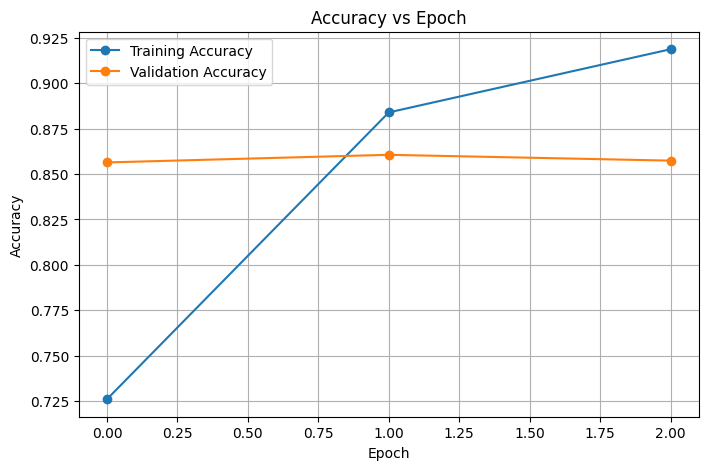

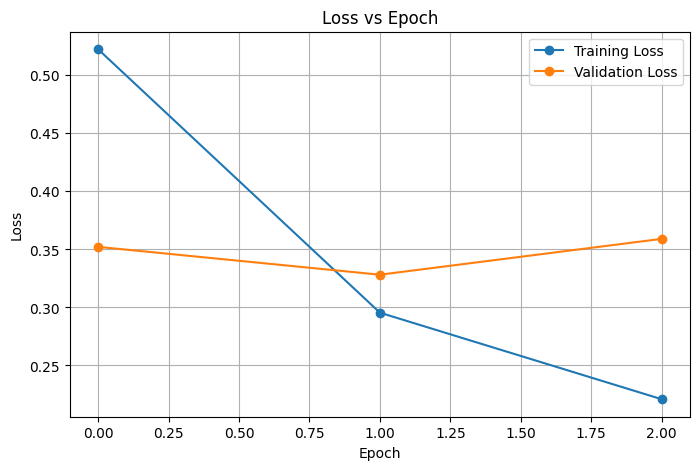

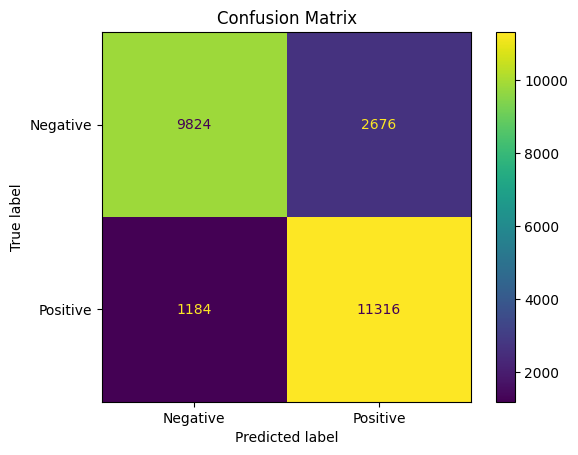


 Priya Dharshini R | Roll No: 24BAD092


In [3]:

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Train the LSTM model
history = model.fit(
    x_train,
    y_train,
    epochs=3,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# Display training and validation metrics
print("\nTraining and Validation Results")

for i in range(len(history.history["accuracy"])):
    print(f"\nEpoch {i + 1}")
    print(f"Training Accuracy: {history.history['accuracy'][i]:.4f}")
    print(f"Validation Accuracy: {history.history['val_accuracy'][i]:.4f}")
    print(f"Training Loss: {history.history['loss'][i]:.4f}")
    print(f"Validation Loss: {history.history['val_loss'][i]:.4f}")

# Evaluate the model on the test dataset
test_loss, test_accuracy = model.evaluate(
    x_test, y_test, verbose=0
)

print("\nTest Results")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Predict sentiment probabilities
probabilities = model.predict(x_test, verbose=0).flatten()

# Convert probabilities to binary labels
y_pred = (probabilities >= 0.5).astype(int)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("\nPerformance Metrics")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

# Plot accuracy versus epoch
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], marker="o", label="Training Accuracy")
plt.plot(history.history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Plot loss versus epoch
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], marker="o", label="Training Loss")
plt.plot(history.history["val_loss"], marker="o", label="Validation Loss")
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Generate and display the confusion matrix
cm = confusion_matrix(y_test, y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

display.plot()
plt.title("Confusion Matrix")
plt.show()

print("\n Priya Dharshini R | Roll No: 24BAD092")

**PART D: SENTIMENT PREDICTION AND DEEP LEARNING EXPERIMENT MANAGEMENT**

**Perform the following tasks:**

•	Provide new movie-review sentences as input to the trained LSTM model.

•	Preprocess and tokenize the input text using the same vocabulary used during training.

•	Apply sequence padding to the input text.

•	Predict the sentiment using the trained LSTM model.

•	Classify the input as Positive or Negative based on the predicted probability.

•	Provide multiple review samples with different sentiments.

•	Compare the predicted sentiment with the actual/expected sentiment.

•	Analyze the coherence and correctness of the model predictions.

•	Document the observations and upload the notebook to GitHub.


In [4]:

# Predict sentiment for new movie reviews

def predict_sentiment(review):
    # Convert the review into lowercase words
    words = re.findall(r"[a-z']+", review.lower())

    # ID 1 is the start token; ID 2 represents unknown words
    numbers = [1]

    for word in words:
        word_id = word_index.get(word)

        if word_id is None or word_id + 3 >= vocab_size:
            numbers.append(2)
        else:
            numbers.append(word_id + 3)

    # Pad the sequence to match the model input length
    padded = pad_sequences(
        [numbers],
        maxlen=max_length,
        padding="post",
        truncating="post"
    )

    # Predict positive sentiment probability
    probability = float(
        model.predict(padded, verbose=0)[0][0]
    )

    sentiment = "Positive" if probability >= 0.5 else "Negative"

    return sentiment, probability


# Test the model with multiple reviews
reviews = [
    (
        "This movie was wonderful and the acting was amazing",
        "Positive"
    ),
    (
        "The film was boring and I hated the story",
        "Negative"
    ),
    (
        "An excellent story with fantastic performances",
        "Positive"
    ),
    (
        "Terrible movie and a complete waste of time",
        "Negative"
    ),
    (
        "I enjoyed the movie and the characters were excellent",
        "Positive"
    ),
    (
        "The movie was disappointing and the acting was poor",
        "Negative"
    )
]

print("SENTIMENT PREDICTION RESULTS\n")

for review, expected in reviews:
    predicted, probability = predict_sentiment(review)

    print("Review:", review)
    print("Expected Sentiment:", expected)
    print("Predicted Sentiment:", predicted)
    print(f"Positive Probability: {probability:.4f}")
    print("Correct Prediction:", expected == predicted)
    print("-" * 60)

print("\n Priya Dharshini R | Roll No: 24BAD092")

SENTIMENT PREDICTION RESULTS

Review: This movie was wonderful and the acting was amazing
Expected Sentiment: Positive
Predicted Sentiment: Positive
Positive Probability: 0.8983
Correct Prediction: True
------------------------------------------------------------
Review: The film was boring and I hated the story
Expected Sentiment: Negative
Predicted Sentiment: Negative
Positive Probability: 0.2103
Correct Prediction: True
------------------------------------------------------------
Review: An excellent story with fantastic performances
Expected Sentiment: Positive
Predicted Sentiment: Positive
Positive Probability: 0.9072
Correct Prediction: True
------------------------------------------------------------
Review: Terrible movie and a complete waste of time
Expected Sentiment: Negative
Predicted Sentiment: Negative
Positive Probability: 0.0500
Correct Prediction: True
------------------------------------------------------------
Review: I enjoyed the movie and the characters were excel